# SSPL + TRPL Multitrap Fitting

This notebook fits a Shockley–Read–Hall multitrap model simultaneously to
steady-state PLQY (SSPL) and/or time-resolved differential lifetime (TRPL)
data using CMA-ES optimisation.

**Workflow**
1. Load data
2. Preprocessing *(optional)*
3. Start-point estimation *(optional)*
4. Fitting
5. Plot fit
6. Export results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

import data_utils as utils
import start_point_estimation_module as spe
import trpl_hyper_cube as hc
import sstrpl_fitting
import sspl_module as sspl
import trpl_module as trpl
from constants import *
import os
from trpl_fitting import load_nn_artifacts

---
## Step 1 — Load Data

Set the file paths and sample parameters.

### SSPL file format (intensity vs PLQY)

The raw SSPL file must have two columns: **intensity in suns** and **PLQY**.
PLQY can be either a fraction (0–1) or in percent (0–100); set
`plqy_in_percent` accordingly in Step 2.

```
intensity_suns   plqy
0.01             0.52
0.10             1.83
1.00             8.71
...              ...        ← values in percent → set plqy_in_percent=True
```

### TRPL file format (time-domain, already preprocessed)

```
time   pl   qfls   tau_diff
1e-9   1.0  0.95   4e-6
...
```

> If your TRPL data is still in raw time-domain form (not yet converted to
> QFLS / τ_diff), use the TRPL preprocessing cells in Step 2.

In [2]:
Eg = 1.625      # bandgap [eV]
npulse = 1.6e17  # pulse energy [J]
d = 450e-7       # thickness [m]


In [3]:
FOLDER = "data"
DATA_FOLDER = os.path.join(FOLDER, "ye-genghua-shallow-t-pl.csv")
trpl_data_raw = pd.read_csv(
    DATA_FOLDER,
    engine="python",
    skiprows=1,
    names=["time", "pl"],
    sep=",",
).set_index("time")

/mnt/c/Users/ro.heumann/Documents/PhDProject/opv_characterization_scripts/Spectroscopy/Optical-Spectroscopy/data_utils.py:534: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  knots_t = torch.tensor(knots, dtype=torch.float32)


Epoch 10/5000, Loss: 19.582287
Epoch 20/5000, Loss: 13.679544
Epoch 30/5000, Loss: 9.311888
Epoch 40/5000, Loss: 6.198447
Epoch 50/5000, Loss: 4.055720
Epoch 60/5000, Loss: 2.614584
Epoch 70/5000, Loss: 1.668390
Epoch 80/5000, Loss: 1.059327
Epoch 90/5000, Loss: 0.669960
Epoch 100/5000, Loss: 0.420403
Epoch 110/5000, Loss: 0.260316
Epoch 120/5000, Loss: 0.158295
Epoch 130/5000, Loss: 0.094276
Epoch 140/5000, Loss: 0.055061
Epoch 150/5000, Loss: 0.031754
Epoch 160/5000, Loss: 0.018348
Epoch 170/5000, Loss: 0.010881
Epoch 180/5000, Loss: 0.006843
Epoch 190/5000, Loss: 0.004705
Epoch 200/5000, Loss: 0.003581
Epoch 210/5000, Loss: 0.002979
Epoch 220/5000, Loss: 0.002637
Epoch 230/5000, Loss: 0.002420
Epoch 240/5000, Loss: 0.002264
Epoch 250/5000, Loss: 0.002138
Epoch 260/5000, Loss: 0.002029
Epoch 270/5000, Loss: 0.001930
Epoch 280/5000, Loss: 0.001839
Epoch 290/5000, Loss: 0.001755
Epoch 300/5000, Loss: 0.001677
Epoch 310/5000, Loss: 0.001604
Epoch 320/5000, Loss: 0.001536
Epoch 330/5000,

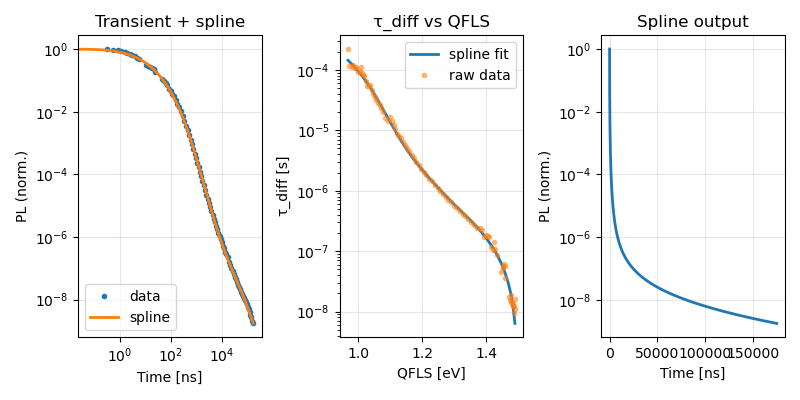

Saved data/trpl_preprocessed_ye-genghua.csv


In [4]:
# ── 2b: TRPL preprocessing — normalize, shift, spline, convert ───────────────
#
# Step 1: build a DataFrame with time (ns) as index and 'pl' column,
#         then trim to the peak and normalize to 1.

trimmed_df = utils.trim_and_normalize(trpl_data_raw)

# Step 2: monotone B-spline fit in log-log space.
#   n_points : number of knots  — increase (e.g. 15) for noisier data
#   n_pred   : number of output points
spline_df = utils.spline_torch(trimmed_df, n_points=5, degree=3, n_pred=256)
# Step 3: (t [ns], PL) → (QFLS [eV], τ_diff [s])
trpl_data = utils.t_pl_to_qfls_tau(spline_df, npulse, Eg)
trpl_data_raw_complete = utils.t_pl_to_qfls_tau(trpl_data_raw, npulse, Eg)
print(f"Preprocessed: {len(trpl_data)} points  |  "
      f"QFLS {trpl_data.qfls.min():.3f} – {trpl_data.qfls.max():.3f} eV  |  "
      f"τ_diff {trpl_data.tau_diff.min():.2e} – {trpl_data.tau_diff.max():.2e} s")

# ── Check plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].loglog(trpl_data_raw.index, trpl_data_raw['pl'], 'o', ms=3, label='data')
axes[0].loglog(spline_df.index,  spline_df['pl'],  lw=2,  label='spline')
axes[0].set_xlabel('Time [ns]'); axes[0].set_ylabel('PL (norm.)')
axes[0].set_title('Transient + spline'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, lw=2, label="spline fit")
axes[1].semilogy(trpl_data_raw_complete.qfls, trpl_data_raw_complete.tau_diff, 'o', ms=3, alpha=0.5, label="raw data")
axes[1].set_xlabel('QFLS [eV]'); axes[1].set_ylabel('τ_diff [s]')
axes[1].set_title('τ_diff vs QFLS'); axes[1].legend();axes[1].grid(True, alpha=0.3)

axes[2].semilogy(trpl_data.index, trpl_data['pl'], lw=2)
axes[2].set_xlabel('Time [ns]'); axes[2].set_ylabel('PL (norm.)')
axes[2].set_title('Spline output'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Optionally save ───────────────────────────────────────────────────────────
trpl_data.to_csv("data/trpl_preprocessed_ye-genghua.csv")
print("Saved data/trpl_preprocessed_ye-genghua.csv")

In [5]:
sspl_path = "data/ye-genghua_sspl_suns_qfls.dat"
sspl_data = pd.read_csv(
    sspl_path,
    engine="python",
    sep=r'\s+',
    skiprows=2,
    names=["intensity_suns", "qfls"]
)

sspl_data.head()

,intensity_suns,qfls
0,0.01932,1.101787
1,0.02595,1.120416
2,0.04188,1.138535
3,0.08791,1.158904
4,0.12973,1.174274


---
## Step 1b — Load Neural-Network Surrogate *(optional)*

The NN surrogate replaces the ODE transient solver during TRPL fitting.
It predicts τ_diff vs. QFLS orders of magnitude faster than the rate-equation
model, at the cost of being limited to the parameter range it was trained on.

Pass the loaded artefacts to `sstrpl_fitting.fit_multitrap` via the
`nn_model`, `nn_input_scaler`, and `nn_output_scaler` keyword arguments
(see Step 4b). Skip this step if you only use the rate-equation fitter.

### Required files

| File | Description |
|------|-------------|
| `model.keras` | Trained Keras model |
| `param_scaler.joblib` | `StandardScaler` for the NN inputs (physical parameters) |
| `output_scaler.joblib` | `MinMaxScaler` for the NN outputs (log₁₀ τ_diff values) |

Place all three files in the same folder and set `NETWORK_FOLDER` below.

### NN input features (order must match training)

| # | Feature | Unit |
|---|---------|------|
| 1 | log₁₀(n_pulse) | cm⁻³ |
| 2 | Eg | eV |
| 3 | log₁₀(krad) | cm³/s |
| 4 | log₁₀(Nt_1) | cm⁻³ |
| 5 | Et_1 / Eg | — |
| 6 | log₁₀(τ_n1) | s |
| 7 | log₁₀(τ_p1) | s |
| … | *(repeat 4–7 for each additional trap)* | |

### NN output

`QFLS_STEPS` (= 256) values of log₁₀(τ_diff) [s] on a fixed QFLS axis
computed analytically from `npulse` and `Eg` via `_compute_qfls_network`.
The axis spans from the initial QFLS right after the pulse down by
`DECAY_MAGNITUDE` (= 12) orders of magnitude in PL intensity.


In [9]:
NETWORK_FOLDER = "network/20260407-231442-3594-2Trap-262128sims"
MODEL_PATH = os.path.join(NETWORK_FOLDER, "model.keras")
PARAM_SCALER_PATH = os.path.join(NETWORK_FOLDER, "2Trap_TRPL_Simulation_07_04_2026_sims_262128_t_256_training_param_scaler.joblib")
OUTPUT_SCALER_PATH = os.path.join(NETWORK_FOLDER, "2Trap_TRPL_Simulation_07_04_2026_sims_262128_t_256_training_output_scaler.joblib")
HDF5_PATH = os.path.join(NETWORK_FOLDER, "2Trap_TRPL_Simulation_07_04_2026_sims_262128_t_256_training.hdf5")

model, scaler_in, scaler_out, qfls_axis = load_nn_artifacts(
    MODEL_PATH, PARAM_SCALER_PATH, OUTPUT_SCALER_PATH, hdf5_path=HDF5_PATH)

# Pass to fit_multitrap via kwargs:
#   nn_model=model, nn_input_scaler=scaler_in, nn_output_scaler=scaler_out, nn_qfls_axis=qfls_axis
# See Step 4b below.


I0000 00:00:1779973397.899563  439650 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779973398.362161  439650 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779973399.938616  439650 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1779973402.418674  439650 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

Loaded QFLS axis from HDF5: [0.7748, 1.4892] eV, 256 points


/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


---
## Step 2 — Preprocessing

### 2a — SSPL: convert intensity → QFLS

The fitting engine works in QFLS space.  The conversion uses:

$$\mathrm{QFLS} = V_{oc,rad}(1sun) + k_BT \ln(\Phi (suns)) + k_BT \ln\!\left(PLQY\right)$$


$V_{oc,rad}(1sun)  = k_B T \ln(J_{sc}/J_{0,rad} + 1)$

$J_{sc} = q \int \alpha(E) \Phi_{AM1.5g} dE$

Sockley-Queisser: $alpha(E) = step(E-Eg)$

$J_{0,rad} = q \int (E, \alpha(E) \Phi_{bb}) dE$

$\Phi_{bb} = 2*pi/h^3/c^2.*E.^2./(exp(E/k_BT)-1)$

$\Phi_{bb}$:black-body spectrum
$\alpha(E)$:absorption coefficient

### 2b — TRPL: spline fit + (t, PL) → (QFLS, τ_diff)

Skip the TRPL cells if you already have a preprocessed TRPL file.

In [28]:
# ── 2a: SSPL preprocessing — intensity (suns) + PLQY  →  QFLS + PLQY ────────
#
# Shockley-Queisser limit: V_oc,rad is computed from blackbody integrals
# (sun at ~5778 K vs device at T).  No krad or DOS parameters needed.
#
# Set plqy_in_percent=True if your PLQY values are in percent (0–100).
# The returned 'plqy' column will always be in fraction (0–1).
sspl_data = utils.preprocess_sspl(
    sspl_raw,
    Eg=Eg,
    T=300.0,             # temperature [K]
    use_sq_limit=True,   # <── SQ-limit: no krad required
    plqy_in_percent=True,
    intensity_col='intensity_suns',
    plqy_col='plqy',
)

print(f"SSPL processed: {len(sspl_data)} points")
print(f"  QFLS range : {sspl_data.qfls.min():.3f} – {sspl_data.qfls.max():.3f} eV")
print(f"  PLQY range : {sspl_data.plqy.min():.3e} – {sspl_data.plqy.max():.3e}")
print(sspl_data.head())

# ── Check plot: intensity vs PLQY and QFLS vs PLQY side by side ──────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.loglog(sspl_data.intensity_suns, sspl_data.plqy, 'o', ms=5, color='#2E86AB')
ax1.set_xlabel('Intensity [suns]')
ax1.set_ylabel('PLQY')
ax1.set_title('SSPL: intensity vs PLQY')
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogy(sspl_data.qfls, sspl_data.plqy, 'o', ms=5, color='#A23B72')
ax2.set_xlabel('QFLS [eV]')
ax2.set_ylabel('PLQY')
ax2.set_title('SSPL: QFLS vs PLQY  (used for fitting)')
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Optionally save the preprocessed SSPL data ───────────────────────────────
sspl_data.to_csv("data/sspl_preprocessed.csv", index=False)
print("Saved data/sspl_preprocessed.csv")

NameError: name 'sspl_raw' is not defined

---
## Step 3 — Start-Point Estimation *(Optional)*

The start-point estimator analyses the curvature of the τ_diff vs. QFLS
curve to identify deep- and shallow-trap regimes and estimate initial
values for Et, Nt, τ_n, and τ_p.

Providing a good initial guess makes CMA-ES converge faster and more
reliably, but a random start also works.

Fitted tau0 shallow: 25163.434


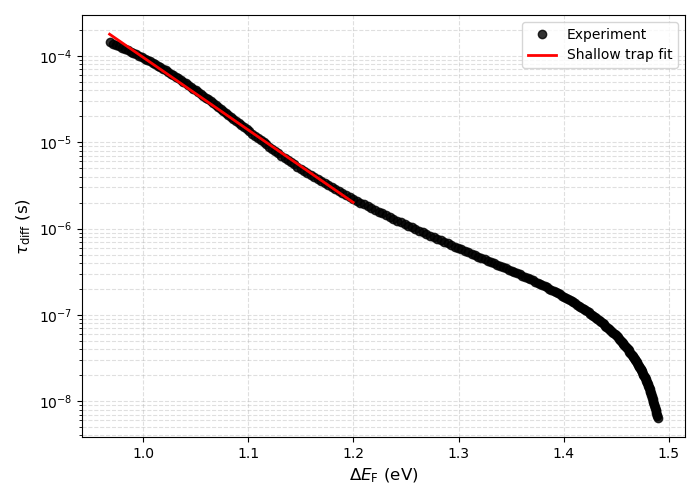

Estimated start point: (array(1.e-11), array(1.325), array(1.97315566e+14), array(1.88542326e-05), array(1.88542326e-05))
Fitted tau0 shallow: 25163.434


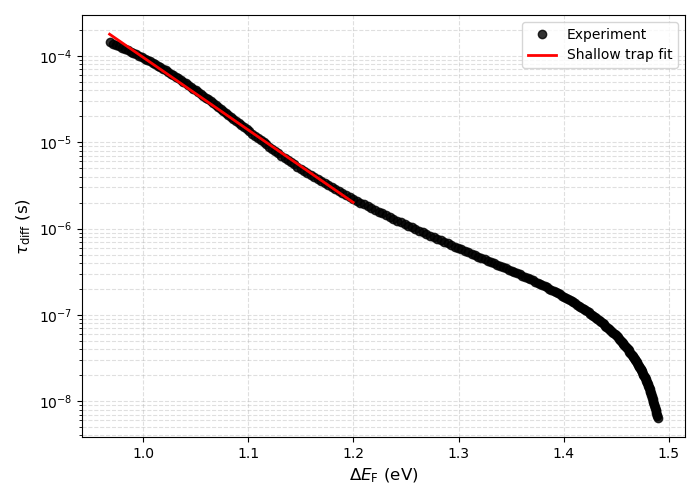

Estimated start point 2: (array(1.e-11), array(1.355), array(6.31182475e+14), array(5.89406982e-06), array(5.89406982e-06))


In [6]:
# ── Run start-point estimator ────────────────────────────────────────────────
trap_type = "shallow"  # 'shallow' for near-band traps, 'deep' for mid-gap

mask_deep, mask_shallow = spe.determine_trap_regime(trpl_data)
trap_mask = mask_shallow if trap_type == "shallow" else mask_deep

trap_mask = (trpl_data.qfls <= 1.2) & (trpl_data.qfls >= 0.9)

start_point = spe.start_point_estimator(
    trpl_data,
    trap_mask,
    Eg,
    trap_type=trap_type,
    photodoping=True,
    dEt=0.3,              # energy offset above estimated trap level [eV]
    Ntrap=1e14,            # initial trap density guess [cm^-3] (only used for deep traps)
)
print("Estimated start point:", start_point)


start_point_2 = spe.start_point_estimator(
    trpl_data,
    trap_mask,
    Eg,
    trap_type=trap_type,
    photodoping=True,
    dEt=0.27,              # energy offset above estimated trap level [eV]
    Ntrap=1e14,            # initial trap density guess [cm^-3] (only used for deep traps)
)
print("Estimated start point 2:", start_point_2)

In [7]:
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid
am15g_path = "data/AM15G.dat"
am15g = pd.read_csv(am15g_path,
                    delim_whitespace=True, 
                    names=['E', 'sunspectrum'])
E=np.linspace(0.4, 4,1000) #am15g.E.max()
am15g_inter = PchipInterpolator(am15g['E'], am15g['sunspectrum'], extrapolate=False)(E)
sq_mask = E >= Eg
E_arr   = E[sq_mask]
phi_sun_arr = am15g_inter[sq_mask]

G = 0.8*trapezoid(phi_sun_arr, E_arr) / d  # 1 sun cm-3 s-1
G

/tmp/ipykernel_439650/1210392070.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  am15g = pd.read_csv(am15g_path,


2.7413430426415813e+21

x0_multitrap length = 9  (expected 9 for 2 traps)


I0000 00:00:1779973407.357834  439972 service.cc:153] XLA service 0x7c40f40356a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779973407.357874  439972 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1779973407.410504  439972 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step


I0000 00:00:1779973407.709543  439972 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


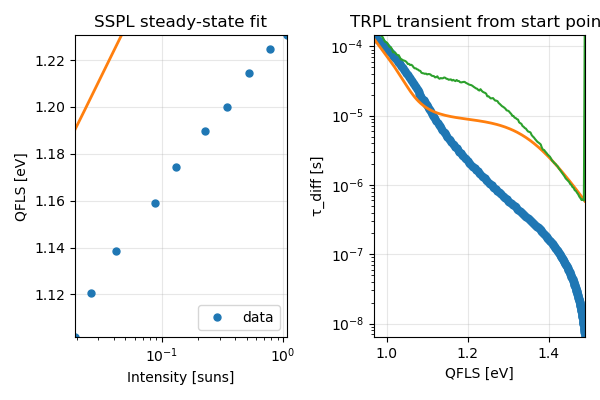

In [10]:
# ── Manual start point ───────────────────────────────────────────────────────
# Fill in values from the estimator or from prior knowledge.
# For a 2-trap model supply two sets of (Et, Nt, tau_n, tau_p).

# Parameter vector layout for num_traps=2:
# [Et_0, Nt_0, tau_n_0, tau_p_0,  Et_1, Nt_1, tau_n_1, tau_p_1,  krad]


# ── CMA-ES start point (x0_multitrap format) ────────────────────────────────
# Layout: [Et_0, Nt_0, tau_n_0, tau_p_0,  Et_1, Nt_1, tau_n_1, tau_p_1,  krad]
# start_point / start_point_2 layout: (krad, Et, Nt, tau_n, tau_p)
x0_multitrap = [
    float(start_point[1]),   float(start_point[2]),   float(start_point[3]),   float(start_point[4]),
    float(start_point_2[1]), float(1.5053), float(start_point_2[3]), float(start_point_2[4]),
    float(start_point[0]),   # krad (shared between both traps)
]
print(f"x0_multitrap length = {len(x0_multitrap)}  (expected {2 * 4 + 1} for 2 traps)")

# ── Network feature vector (x0_nn) — for direct NN preview only ─────────────
# Layout: [log10(npulse), Eg, log10(krad),
#          log10(Nt_1), Et_1/Eg, log10(taun_1), log10(taup_1),
#          log10(Nt_2), Et_2/Eg, log10(taun_2), log10(taup_2)]
# NOTE: Eg is stored as linear eV (not log10), matching the training data.
x0_nn = np.concatenate([
    [np.log10(npulse)],
    [Eg],
    [np.log10(start_point[0])],
    [np.log10(start_point[2])], [start_point[1]/Eg], [np.log10(start_point[3])], [np.log10(start_point[4])],
    [np.log10(start_point_2[2])], [1.5053/Eg], [np.log10(start_point_2[3])], [np.log10(start_point_2[4])],
])
import constants
(
    t_start,
    n_tr_start,
    p_tr_start,
    nt_tr_start,
    qfls_tr_start,
    tau_tr_start,
    tau_tr_n_start,
    tau_tr_p_start,
    pl_tr_start,
    e_trapping_start,
    e_detrapping_start,
    h_trapping_start,
    h_detrapping_start,
    krad_rate_start,
) = trpl.solve_transient(
    tarr=[1e-10,1e5], 
    npulse=npulse, 
    Eg=Eg, 
    Nc=constants.NC, 
    Nv=constants.NV, 
    krad=start_point[0], 
    Nt=np.concatenate([[start_point[2], start_point_2[2]]]),
    Et=np.concatenate([[start_point[1], start_point_2[1]]]),
    taun=np.concatenate([[start_point[3], start_point_2[3]]]),
    taup=np.concatenate([[start_point[4], start_point_2[4]]]),
    T=300, 
    bias=0
)


(
    narr, 
    parr, 
    ntmat, 
    Rtotarr, 
    Rradarr, 
    Rsrhmat,
    qfls_ss, 
    plqy_ss, 
    tau_ss, 
    tau_ss_n, 
    tau_ss_p, 
    nid,
    e_trapping, 
    e_detrapping, 
    h_trapping, 
    h_detrapping
) = sspl.solve_steady_state(
    Npoints=1000, 
    Eg=Eg, 
    Nc=constants.NC, 
    Nv=constants.NV, 
    krad=start_point[0], 
    Nt=np.concatenate([[start_point[2], start_point_2[2]]]),
    Et=np.concatenate([[start_point[1], start_point_2[1]]]),
    taun=np.concatenate([[start_point[3], start_point_2[3]]]),
    taup=np.concatenate([[start_point[4], start_point_2[4]]]),
    T=300
)


#network

x0_transformed = scaler_in.transform(x0_nn.reshape(1,-1))
tau_predict = 10**scaler_out.inverse_transform(model.predict(x0_transformed)).flatten()




plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].semilogx(sspl_data.intensity_suns, sspl_data.qfls, 'o', ms=5, label='data')
ax[0].semilogx(Rtotarr/G, qfls_ss, lw=2)
ax[0].set_ylabel('QFLS [eV]')
ax[0].set_xlabel('Intensity [suns]')
ax[0].set_title('SSPL steady-state fit')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(sspl_data.intensity_suns.min(),sspl_data.intensity_suns.max())
ax[0].set_ylim(sspl_data.qfls.min(), sspl_data.qfls.max())
ax[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, 'o', ms=5, label='data')
ax[1].semilogy(qfls_tr_start, tau_tr_start, lw=2)
ax[1].semilogy(qfls_axis, tau_predict, label='network')
ax[1].set_xlabel('QFLS [eV]')
ax[1].set_ylabel('τ_diff [s]')
ax[1].set_xlim(trpl_data.qfls.min(),trpl_data.qfls.max())
ax[1].set_ylim(trpl_data.tau_diff.min(), trpl_data.tau_diff.max())
ax[1].set_title('TRPL transient from start point')
ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
x0_multitrap

[1.325,
 197315566230139.75,
 1.8854232578499465e-05,
 1.8854232578499465e-05,
 1.355,
 1.5053,
 5.894069824699644e-06,
 5.894069824699644e-06,
 1e-11]

In [23]:
#os.mkdir("fit-ye-genghua-2traps-trials1-sspl-trpl")

export = pd.DataFrame({
    'qfls_tr': qfls_tr_start,
    'tau_diff_tr': tau_tr_start,
})
export.to_csv("fit-ye-genghua-low-Nt-no-photodoping-2traps/trpl_startpoint_rem_sim_ye-genghua.csv", index=False)

export = pd.DataFrame({
    'qfls_axis': qfls_axis,
    'tau_predict': tau_predict
})
export.to_csv("fit-ye-genghua-low-Nt-no-photodoping-2traps/trpl_startpoint_network_sim_ye-genghua.csv", index=False)

export = pd.DataFrame({
    'intensity_suns': Rtotarr/G,
    'qfls': qfls_ss,
})
export.to_csv("fit-ye-genghua-low-Nt-no-photodoping-2traps/sspl_trpl_startpoint_sim_ye-genghua.csv", index=False)


---
## Step 4 — Fitting

### 4a — Rate-equation fit (`sstrpl_fitting.fit_multitrap`)

Fits SSPL and/or TRPL simultaneously using the full ODE solver.

| Parameter | Description | Typical values |
|-----------|-------------|----------------|
| `num_traps` | Number of SRH trap levels | 1 or 2 |
| `fit_mode` | Which dataset(s) to fit | `'both'`, `'sspl'`, `'trpl'` |
| `error_type` | Error metric | `'mse'`, `'mae'`, `'integral_mae'`, `'integral_mse'` |
| `n_interp_sspl/trpl` | Uniform QFLS grid size for error | `None` or 100–500 |
| `qfls_range_sspl/trpl` | QFLS window for error [eV] | `None` or `(0.90, 1.15)` |
| `w_sspl` / `w_trpl` | Dataset weights (only for `fit_mode='both'`) | `1.0` |
| `trials` | Independent CMA-ES restarts (best kept) | 1–10 |
| `maxfevals` | Max objective evaluations per restart | 20 000–100 000 |
| `sigma` | CMA-ES initial step size in normalised space | 0.1–0.3 |
| `ftarget` | Stop early if error drops below this value | `1e-2` |
| `termination_period` | Generations between convergence checks | 50–200 |
| `Et_bounds` | Trap energy search range [eV] | `(Eg/2, Eg)` |
| `Nt_bounds` | Trap density search range [cm⁻³] | `(1e12, 1e20)` |
| `tau_n_bounds` | Electron SRH lifetime range [s] | `(1e-12, 1e-4)` |
| `tau_p_bounds` | Hole SRH lifetime range [s] | `(1e-12, 1e-4)` |
| `krad_bounds` | Radiative rate range [cm³/s] | `(1e-12, 1e-9)` |
| `fixed_params` | Pin parameters out of the search space | `{}` |
| `Ngrid` | QFLS grid points for the steady-state solver | 1000 |
| `tspan` | Time span for the TRPL transient solver [s] | `[1e-11, 1e5]` |
| `x0_multitrap` | Manual initial guess vector (length `4K+1`) | `None` |

All bound arguments accept either a single `(lo, hi)` tuple (same for all
traps) or a list of `(lo, hi)` tuples with one entry per trap.

---

### 4b — Neural-network fit (`sstrpl_fitting.fit_multitrap` with NN kwargs)

Pass the artefacts loaded in Step 1b to the same `fit_multitrap` function via
three keyword arguments. The NN replaces the ODE transient solver for the TRPL
part of the objective; SSPL still uses the steady-state solver when
`fit_mode='both'`.

| Kwarg | Description |
|-------|-------------|
| `nn_model` | Trained Keras model (from `load_nn_artifacts`) |
| `nn_input_scaler` | `StandardScaler` for NN inputs |
| `nn_output_scaler` | `MinMaxScaler` for NN outputs |

All other parameters from Step 4a apply unchanged. Note that `fit_mode='sspl'`
raises an error when `nn_model` is provided (the NN only affects TRPL).

> **Multi-curve fitting:** pass a *list* of DataFrames as `df_trpl` and a
> matching list of floats as `npulse` — same as the ODE fitter. Each curve
> gets its own NN QFLS axis computed from its `npulse`; the objective averages
> the error across curves.

In [13]:
# ── Fitting configuration ────────────────────────────────────────────────────
import constants
import trpl_fitting


num_traps = 2

params = {
    # Initial guess — set to None for a random start
    'x0_multitrap': x0_multitrap,

    # Which dataset(s) to fit: 'both' | 'sspl' | 'trpl'
    'fit_mode': 'both',

    # Error metric: 'mse' | 'mae' | 'integral_mae' | 'integral_mse'
    'error_type': 'rmse',
    'sspl_residual_type':'intensity_suns_qfls',
    'G_per_sun': G,  # only needed if sspl_residual_type='intensity_qfls'   

    # Uniform QFLS interpolation grid (None = use raw data points)
    'n_interp_sspl': None,
    'n_interp_trpl': None,

    # Restrict error to a QFLS window [eV]  (None = full range)
    'qfls_range_sspl': None,
    'qfls_range_trpl': None, #[trpl_data.qfls.min(), 1.4],

    # Relative dataset weights (only used when fit_mode='both')
    'w_sspl': 1.0,
    'w_trpl': 1.0,

    # CMA-ES settings
    'sigma':     0.25,    # initial step size in normalised space (0.1–0.3)
    'trials':    1,       # independent restarts; best result is kept
    'ftarget':   1e-3,    # stop if error < ftarget
    'termination_period':   100,      # generations between restarts (if trials > 1)
    # Parameter search bounds
    # Each bound accepts either a single (lo, hi) tuple (same for all traps)
    # or a list of (lo, hi) tuples with one entry per trap.
    #'Et_bounds':    (Eg / 2, Eg),    # trap energy [eV]       — single bound → all traps
    'Et_bounds':  [(0.5*Eg, 0.975*Eg), (0.5*Eg, 0.975*Eg)],  # NN DeltaEtrap training max is 0.975
    'Nt_bounds':    [(1e12, 1e14), (1e12, 1e15)],    # trap density [cm^-3]
    #'tau_n_bounds': (1e-12, 1e-4),   # electron SRH lifetime [s]
    'tau_n_bounds': [(1e-12,1e-4), (1e-12,1e-4)],
    #'tau_p_bounds': (1e-12, 1e-4),   # hole SRH lifetime [s]
    'tau_p_bounds': [(1e-12,1e-4), (1e-12,1e-4)],
    'krad_bounds':  (1e-12, 1e-10),  # radiative rate coefficient [cm^3/s] — matches NN training range

    # Fixed parameters (optional) — remove these dimensions from the optimiser.
    # Keys: 0-based trap index → dict of param name → value; or 'krad' → value.
    # Param names: 'Et', 'Nt', 'tau_n', 'tau_p'
    # 'fixed_params': {},            # ← default: nothing fixed
    'fixed_params': {1: {'Et': 1.5053}},  # ← example
    'nn_model': model,
    'nn_input_scaler': scaler_in,
    'nn_output_scaler': scaler_out,
    'nn_qfls_axis': qfls_axis,   # QFLS axis loaded from training HDF5
    # Steady-state and transient solver settings
    'Ngrid': 1000,              # QFLS grid points for steady-state solver
    'tspan': [1e-11, 1e5],      # time span for TRPL transient [s]
}

# ── Single TRPL curve (standard usage) ───────────────────────────────────────
results = sstrpl_fitting.fit_multitrap(
    sspl_data,    # DataFrame with columns ['qfls', 'plqy']  (from Step 2)
    trpl_data,    # DataFrame with columns ['qfls', 'tau_diff']
    Eg,
    npulse,       # scalar excited carrier density [cm^-3]
    num_traps=num_traps,
    **params,
)

# ── Multiple TRPL curves (simultaneous fit, one npulse per curve) ─────────────
# Uncomment and adapt when you have several fluence-dependent TRPL curves.
# All curves share the same trap parameters; only npulse differs between them.
#
# results = sstrpl_fitting.fit_multitrap(
#     sspl_data,
#     trpl_data_list,     # list of DataFrames, one per curve
#     Eg,
#     npulse_list,        # list of floats, one per curve  [cm^-3]
#     num_traps=num_traps,
#     **params,
# )


# ── NN surrogate fit (Step 4b) — uncomment to use ───────────────────────────
# Requires Step 1b (load_nn_artifacts) to have been run first.
# results = sstrpl_fitting.fit_multitrap(
#     sspl_data,    # or None if fit_mode='trpl'
#     trpl_data,    # DataFrame or list of DataFrames
#     Eg,
#     npulse,       # scalar or list of floats
#     num_traps=num_traps,
#     nn_model=model,
#     nn_input_scaler=scaler_in,
#     nn_output_scaler=scaler_out,
#     fit_mode='trpl',   # 'trpl' or 'both' — not 'sspl'
#     **params,
# )

# ── Print summary ────────────────────────────────────────────────────────────
print(results['params'].to_string(index=False))
print(f"\nkrad = {results['krad_cm3s']:.3e} cm³/s")
print(f"\nTotal error : {results['error_total']:.6f}  ({results['error_type']})")
if results['error_sspl'] is not None:
    print(f"SSPL error  : {results['error_sspl']:.6f}")
if results['error_trpl'] is not None:
    print(f"TRPL error  : {results['error_trpl']:.6f}")
    if results['error_trpl_per_curve'] and len(results['error_trpl_per_curve']) > 1:
        for i, (ec, np_i) in enumerate(zip(results['error_trpl_per_curve'],
                                           results['trpl_npulse_list'])):
            print(f"  Curve {i+1}  : {ec:.6f}  (npulse = {np_i:.3e} cm⁻³)")
print(f"\nSolve time  : {results['solve_time']:.1f} s  |  "
      f"{results['n_evals']} evaluations  |  "
      f"{results['n_gens']} generations")

MULTITRAP MODEL FITTING - CMA-ES OPTIMIZATION
TRPL surrogate  : NEURAL NETWORK
Number of traps : 2
Free parameters : 8  (of 9 total)
  Fixed: trap 1, Et = 1.505
Fit mode        : both
Error type      : rmse
SSPL residuals  : intensity_suns_qfls
G_per_sun       : 2.7413e+21 photons/cm²/s  (user-supplied)
SSPL data points: 10
TRPL curves     : 1
TRPL data points: 256 total
  Curve 1: 256 pts, npulse = 1.600e+17 cm⁻³
Total data points: 266

===== Fit 1/1 =====

Starting values:
  Trap 1: Et=1.325 eV, Nt=1.00e+14 cm⁻³, τn=1.89e-05 s, τp=1.89e-05 s
  Trap 2: Et=1.505 eV, Nt=1.00e+12 cm⁻³, τn=5.89e-06 s, τp=5.89e-06 s
  krad=1.00e-11 cm³/s

Starting RMSE: 1.309533

Optimizing...
----------------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min     |     sigma     | min_std  | max_std  |   axis  
     1 |        1 |  1.3095331312 |  1.3095331312 |  0.2500000000 |  0.25000 |  0.25001 |  1.00004
     2 |       11 |  4.006155E+03 |  0.7190724395

In [ ]:
x0_multitrap = [
    float(start_point[1]),   float(start_point[2]),   float(start_point[3]),   float(start_point[4]),
    float(start_point[0]),   # krad (shared between both traps)
]


NETWORK_FOLDER = "network/20260401-165841-3577-1Trap-65536sims"
MODEL_PATH = os.path.join(NETWORK_FOLDER, "model.keras")
PARAM_SCALER_PATH = os.path.join(NETWORK_FOLDER, "1Trap_TRPL_Simulation_01_04_2026_sims_65536_t_256_training_param_scaler.joblib")
OUTPUT_SCALER_PATH = os.path.join(NETWORK_FOLDER, "1Trap_TRPL_Simulation_01_04_2026_sims_65536_t_256_training_output_scaler.joblib")
HDF5_PATH = os.path.join(NETWORK_FOLDER, "1Trap_TRPL_Simulation_01_04_2026_sims_65536_t_256_training.hdf5")

model, scaler_in, scaler_out, qfls_axis = load_nn_artifacts(
    MODEL_PATH, PARAM_SCALER_PATH, OUTPUT_SCALER_PATH, hdf5_path=HDF5_PATH)

# Pass to fit_multitrap via kwargs:
#   nn_model=model, nn_input_scaler=scaler_in, nn_output_scaler=scaler_out, nn_qfls_axis=qfls_axis
# See Step 4b below.




num_traps = 1

params = {
    # Initial guess — set to None for a random start
    'x0_multitrap': x0_multitrap,

    # Which dataset(s) to fit: 'both' | 'sspl' | 'trpl'
    'fit_mode': 'trpl',

    # Error metric: 'mse' | 'mae' | 'integral_mae' | 'integral_mse'
    'error_type': 'rmse',

    # Uniform QFLS interpolation grid (None = use raw data points)
    'n_interp_sspl': None,
    'n_interp_trpl': None,

    # Restrict error to a QFLS window [eV]  (None = full range)
    'qfls_range_sspl': None,
    'qfls_range_trpl': None, #[trpl_data.qfls.min(), 1.4],

    # Relative dataset weights (only used when fit_mode='both')
    'w_sspl': 1.0,
    'w_trpl': 1.0,

    # CMA-ES settings
    'sigma':     0.25,    # initial step size in normalised space (0.1–0.3)
    'trials':    1,       # independent restarts; best result is kept
    'ftarget':   1e-3,    # stop if error < ftarget
    'termination_period':   100,      # generations between restarts (if trials > 1)
    # Parameter search bounds
    # Each bound accepts either a single (lo, hi) tuple (same for all traps)
    # or a list of (lo, hi) tuples with one entry per trap.
    #'Et_bounds':    (Eg / 2, Eg),    # trap energy [eV]       — single bound → all traps
    'Et_bounds':  (0.5*Eg, 0.975*Eg),  # NN DeltaEtrap training max is 0.975
    'Nt_bounds':    (1e16, 1e18),    # trap density [cm^-3]
    #'tau_n_bounds': (1e-12, 1e-4),   # electron SRH lifetime [s]
    'tau_n_bounds': (1e-12,1e-4),
    #'tau_p_bounds': (1e-12, 1e-4),   # hole SRH lifetime [s]
    'tau_p_bounds': (1e-12,1e-4),
    'krad_bounds':  (1e-12, 1e-10),  # radiative rate coefficient [cm^3/s] — matches NN training range

    # Fixed parameters (optional) — remove these dimensions from the optimiser.
    # Keys: 0-based trap index → dict of param name → value; or 'krad' → value.
    # Param names: 'Et', 'Nt', 'tau_n', 'tau_p'
    # 'fixed_params': {},            # ← default: nothing fixed
    #'fixed_params': {0: {'Et': Eg/2}},  # ← example
    'nn_model': model,
    'nn_input_scaler': scaler_in,
    'nn_output_scaler': scaler_out,
    'nn_qfls_axis': qfls_axis,   # QFLS axis loaded from training HDF5
    # Steady-state and transient solver settings
    'Ngrid': 1000,              # QFLS grid points for steady-state solver
    'tspan': [1e-11, 1e5],      # time span for TRPL transient [s]
}

# ── Single TRPL curve (standard usage) ───────────────────────────────────────
results = sstrpl_fitting.fit_multitrap(
    None,    # DataFrame with columns ['qfls', 'plqy']  (from Step 2)
    trpl_data,    # DataFrame with columns ['qfls', 'tau_diff']
    Eg,
    npulse,       # scalar excited carrier density [cm^-3]
    num_traps=num_traps,
    **params,
)

# ── Multiple TRPL curves (simultaneous fit, one npulse per curve) ─────────────
# Uncomment and adapt when you have several fluence-dependent TRPL curves.
# All curves share the same trap parameters; only npulse differs between them.
#
# results = sstrpl_fitting.fit_multitrap(
#     sspl_data,
#     trpl_data_list,     # list of DataFrames, one per curve
#     Eg,
#     npulse_list,        # list of floats, one per curve  [cm^-3]
#     num_traps=num_traps,
#     **params,
# )


# ── NN surrogate fit (Step 4b) — uncomment to use ───────────────────────────
# Requires Step 1b (load_nn_artifacts) to have been run first.
# results = sstrpl_fitting.fit_multitrap(
#     sspl_data,    # or None if fit_mode='trpl'
#     trpl_data,    # DataFrame or list of DataFrames
#     Eg,
#     npulse,       # scalar or list of floats
#     num_traps=num_traps,
#     nn_model=model,
#     nn_input_scaler=scaler_in,
#     nn_output_scaler=scaler_out,
#     fit_mode='trpl',   # 'trpl' or 'both' — not 'sspl'
#     **params,
# )

# ── Print summary ────────────────────────────────────────────────────────────
print(results['params'].to_string(index=False))
print(f"\nkrad = {results['krad_cm3s']:.3e} cm³/s")
print(f"\nTotal error : {results['error_total']:.6f}  ({results['error_type']})")
if results['error_sspl'] is not None:
    print(f"SSPL error  : {results['error_sspl']:.6f}")
if results['error_trpl'] is not None:
    print(f"TRPL error  : {results['error_trpl']:.6f}")
    if results['error_trpl_per_curve'] and len(results['error_trpl_per_curve']) > 1:
        for i, (ec, np_i) in enumerate(zip(results['error_trpl_per_curve'],
                                           results['trpl_npulse_list'])):
            print(f"  Curve {i+1}  : {ec:.6f}  (npulse = {np_i:.3e} cm⁻³)")
print(f"\nSolve time  : {results['solve_time']:.1f} s  |  "
      f"{results['n_evals']} evaluations  |  "
      f"{results['n_gens']} generations")

I0000 00:00:1778498867.658638   23423 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778498868.098834   23423 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778498869.976465   23423 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1778498872.288755   23423 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

Loaded QFLS axis from HDF5: [0.7748, 1.4892] eV, 256 points
MULTITRAP MODEL FITTING - CMA-ES OPTIMIZATION
TRPL surrogate  : NEURAL NETWORK
Number of traps : 1
Free parameters : 5  (of 5 total)
Fit mode        : trpl
Error type      : rmse
SSPL data points: 0
TRPL curves     : 1
TRPL data points: 256 total
  Curve 1: 256 pts, npulse = 1.600e+17 cm⁻³
Total data points: 256

===== Fit 1/1 =====

Starting values:
  Trap 1: Et=1.475 eV, Nt=6.91e+16 cm⁻³, τn=5.95e-08 s, τp=5.95e-08 s
  krad=1.00e-11 cm³/s


I0000 00:00:1778498873.049471   23640 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778498873.210430   23640 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Starting RMSE: 0.416664

Optimizing...
----------------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min     |     sigma     | min_std  | max_std  |   axis  
     1 |        1 |  0.4166640631 |  0.4166640631 |  0.2500000000 |  0.25000 |  0.25001 |  1.00004
     2 |        9 |  1.3199422573 |  0.4166640631 |  0.2533504647 |  0.22235 |  0.26715 |  1.43942
     3 |       17 |  0.9112732475 |  0.3577858581 |  0.2819818512 |  0.24442 |  0.34702 |  1.63005
     4 |       25 |  1.0956806963 |  0.3577858581 |  0.2881470739 |  0.24107 |  0.36560 |  1.87017
     5 |       33 |  0.8234936479 |  0.3577858581 |  0.2914682179 |  0.24744 |  0.35072 |  2.02559
     6 |       41 |  0.8712974703 |  0.3577858581 |  0.2675408214 |  0.22380 |  0.30747 |  2.08726
     7 |       49 |  0.8173922748 |  0.3577858581 |  0.2373079905 |  0.18555 |  0.26561 |  2.13189
     8 |       57 |  0.7101392526 |  0.3577858581 |  0.2193374677 |  0.17034 |  0.23142 |  2.1361

---
## Step 5 — Plot Fit

Figure saved to fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2-traps-fit-trpl.png


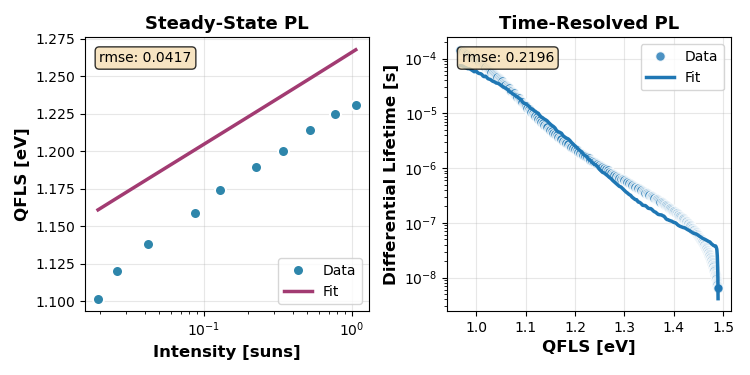

In [14]:
# ── Data vs. fit ─────────────────────────────────────────────────────────────
export_name = "fit-ye-genghua-low-Nt-no-photodoping-2traps-3"
os.mkdir(f"{export_name}")
fig_fit, axes_fit = sstrpl_fitting.plot_fit(
    results,
    save_path=f"{export_name}/2-traps-fit-trpl.png",   # set to None to skip saving
)
plt.show()

Good points (≤1.0): 3406  |  Bad: 45
Corner plot saved to fit-ye-genghua-low-Nt-no-photodoping-2traps-3/1traps-corner-trpl.png


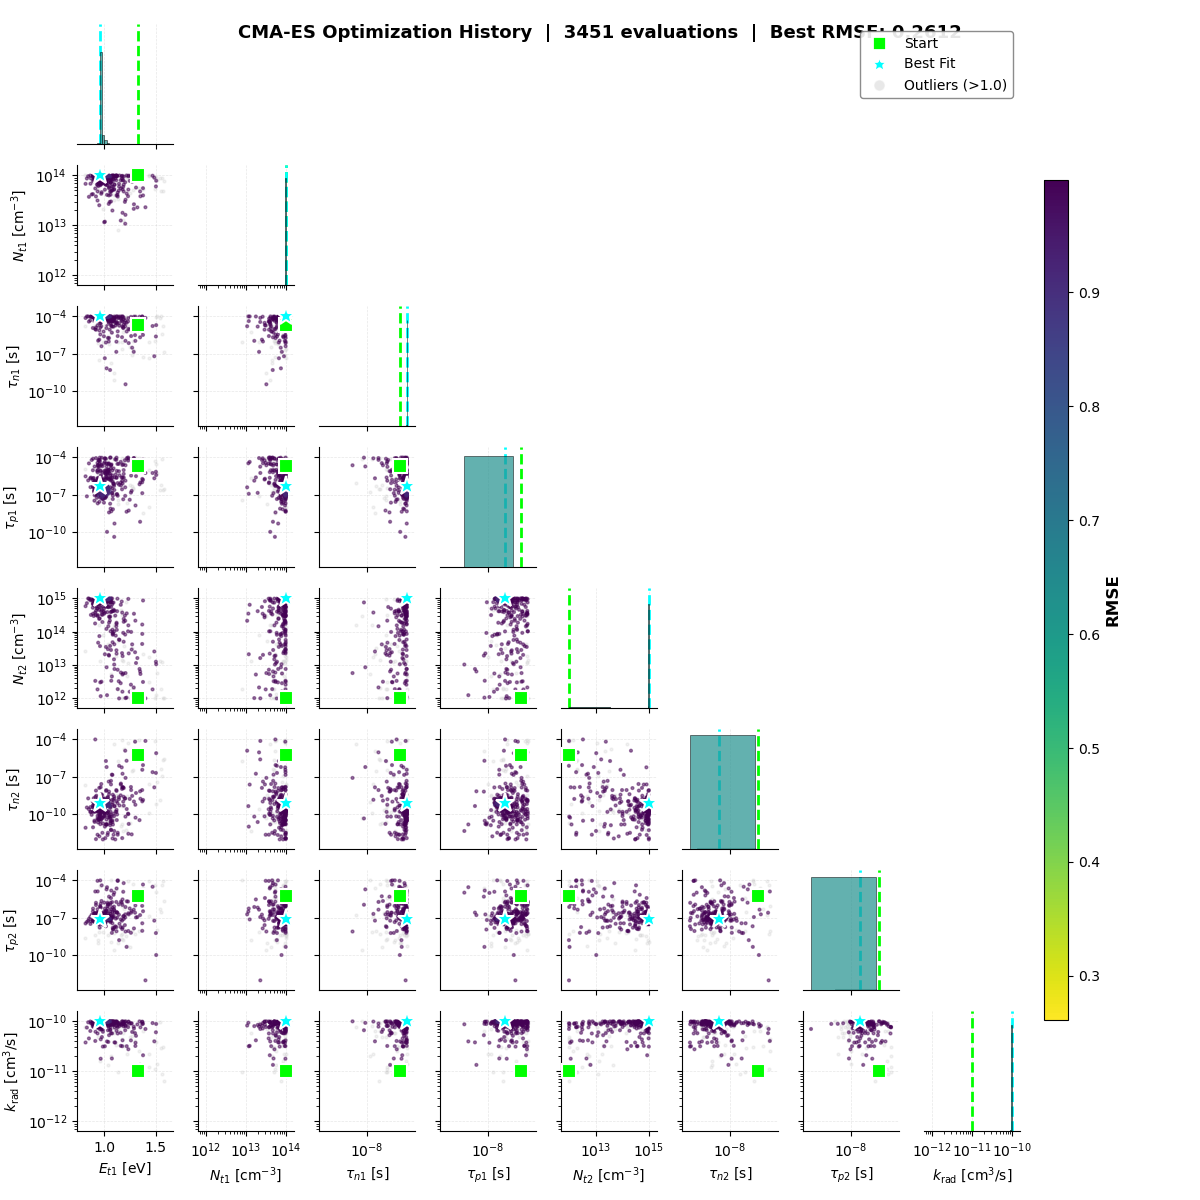

In [15]:
# ── CMA-ES history corner plot ────────────────────────────────────────────────
# error_threshold: evaluations above this value are shown in grey
fig_corner = sstrpl_fitting.plot_corner(
    results,
    max_points=5000,
    error_threshold=1.0,
    save_path=f"{export_name}/1traps-corner-trpl.png",   # set to None to skip saving
)
plt.show()

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1000000000000D-09   r2 =  0.1571181524645D-28
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1000000000000D-09   r2 =  0.1571181524645D-28


/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/home/robin/miniforge3/envs/tf/lib/python3.12/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: in

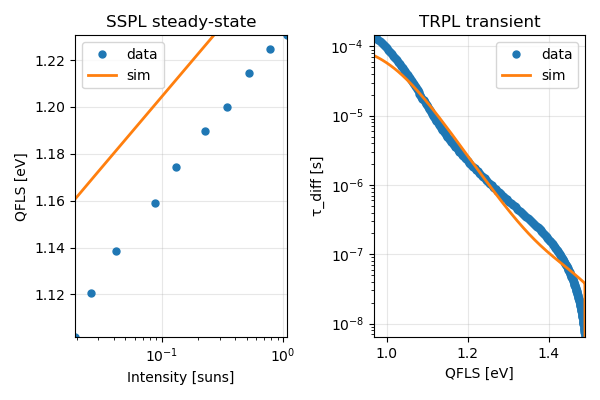

In [16]:
# ── Simulate steady-state + transient from best-fit (or custom) parameters ────
# Edit the block below to override fitted values, or leave as-is to replot
# exactly the best-fit result.
import constants

# ── Parameters (edit here) ────────────────────────────────────────────────────
krad_plot = results['krad_cm3s']                         # cm³/s
Et_plot   = results['params']['Et_eV'].values.copy()     # eV,   one per trap
Nt_plot   = results['params']['Nt_1/cm3'].values.copy()  # cm⁻³, one per trap
taun_plot = results['params']['tau_n_s'].values.copy()   # s,    one per trap
taup_plot = results['params']['tau_p_s'].values.copy()   # s,    one per trap


# Example: override individual values
# krad_plot    = 1e-11
# Et_plot     = np.array([ 1.5250]) #1.4750,
# Nt_plot     = np.array([4.7286e+17]) #6.9112e+16, 
# taun_plot   = np.array([ 8.6892e-09]) #5.9451e-08,
# taup_plot   = np.array([ 8.6892e-09]) #5.9451e-08,


#krad_plot    = 5.7871e-11
#Et_plot   = 1.3958
#Et_plot   = 1.5724
#Nt_plot   = 2.8703e+15
#Nt_plot   = 4.3392e+17
#taun_plot = 1.0482e-08
#taun_plot = 6.3897e-09
#taup_plot = 1.2305e-06
#taup_plot = 1.3652e-08

# ── Transient simulation ──────────────────────────────────────────────────────
(
    t, n_tr, p_tr, nt_tr, QFLS_tr, tau_tr, tau_tr_n, tau_tr_p, PL_tr,
    e_trapping_tr, e_detrapping_tr, h_trapping_tr, h_detrapping_tr, krad_rate_tr
) = trpl.solve_transient(
    tarr=[1e-10, 1e5],
    npulse=npulse,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300,
    bias=0
)

# ── Steady-state simulation ───────────────────────────────────────────────────
(
    narr, parr, ntmat, Rtotarr, Rradarr, Rsrhmat,
    qfls_ss, plqy_ss, tau_ss, tau_ss_n, tau_ss_p, nid,
    e_trapping, e_detrapping, h_trapping, h_detrapping
) = sspl.solve_steady_state(
    Npoints=1000,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300
)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

ax[0].semilogx(sspl_data.intensity_suns, sspl_data.qfls, 'o', ms=5, label='data')
ax[0].semilogx(Rtotarr / G, qfls_ss, lw=2, label='sim')
ax[0].set_ylabel('QFLS [eV]')
ax[0].set_xlabel('Intensity [suns]')
ax[0].set_title('SSPL steady-state')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(sspl_data.intensity_suns.min(), sspl_data.intensity_suns.max())
ax[0].set_ylim(sspl_data.qfls.min(), sspl_data.qfls.max())

ax[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, 'o', ms=5, label='data')
ax[1].semilogy(QFLS_tr, tau_tr, lw=2, label='sim')
ax[1].set_xlabel('QFLS [eV]')
ax[1].set_ylabel('τ_diff [s]')
ax[1].set_title('TRPL transient')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(trpl_data.qfls.min(), trpl_data.qfls.max())
ax[1].set_ylim(trpl_data.tau_diff.min(), trpl_data.tau_diff.max())

plt.tight_layout()
plt.show()


---
## Step 6 — Export Results

| Key in `results` | Contents |
|------------------|----------|
| `sspl_sim` | Full steady-state simulation (Ngrid points) |
| `trpl_sim` | Full transient simulation (time-domain) |
| `sspl_fit` | SSPL data vs. fit on the comparison QFLS grid |
| `trpl_fit` | TRPL data vs. fit on the comparison QFLS grid |
| `params`   | Fitted trap parameters (Et, Nt, τ_n, τ_p) |
| `krad_cm3s`| Fitted radiative rate coefficient |

In [17]:
# ── Set export directory and file prefix ─────────────────────────────────────
export_dir    = export_name  # created automatically if absent
export_prefix = "2traps-trpl"

# ── Standard export (TRPL fit, parameters JSON, history, summary) ────────────
exported = utils.export_fit_results(
    results,
    output_dir=export_dir,
    prefix=export_prefix,
)

# ── Export SSPL simulation ────────────────────────────────────────────────────
if results['sspl_sim'] is not None:
    path = f"{export_dir}/{export_prefix}_sspl_sim.csv"
    results['sspl_sim'].to_csv(path, index=False, float_format='%.6e')
    print(f"✓ Exported SSPL simulation to: {path}")

# ── Export SSPL fit (data vs. model on comparison grid) ──────────────────────
if results['sspl_fit'] is not None:
    path = f"{export_dir}/{export_prefix}_sspl_fit.csv"
    results['sspl_fit'].to_csv(path, index=False, float_format='%.6e')
    print(f"✓ Exported SSPL fit to: {path}")

print("\nDone. All files written to:", export_dir)

✓ Exported TRPL fit to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_trpl.csv
✓ Exported TRPL sim to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_trpl.csv
✓ Exported parameters to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_parameters.json
✓ Exported optimization history to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_history.npz
  - 3451 evaluations across 346 generations
✓ Exported summary to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_summary.txt

✅ All results exported to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3
✓ Exported SSPL simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_sspl_sim.csv
✓ Exported SSPL fit to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_sspl_fit.csv

Done. All files written to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3


In [18]:
export_dir    = export_name  # created automatically if absent
export_prefix = "2traps-trpl"

os.makedirs(export_dir, exist_ok=True)

export_transient = pd.DataFrame({
    't_s': t,
    'n_tr_cm3': n_tr,
    'p_tr_cm3': p_tr,
    **{f'nt_tr_cm3_{i}': nt_tr[:,i] for i in range(len(nt_tr[0]))},
    'QFLS_tr': QFLS_tr,
    'tau_tr_s': tau_tr,
    'tau_tr_n_s': tau_tr_n,
    'tau_tr_p_s': tau_tr_p,
    'PL_tr': PL_tr,
    **{f'e_trapping_cm3_s_{i}': e_trapping_tr[:, i] for i in range(e_trapping_tr.shape[1])},
    **{f'e_detrapping_cm3_s_{i}': e_detrapping_tr[:, i] for i in range(e_detrapping_tr.shape[1])},
    **{f'h_trapping_cm3_s_{i}': h_trapping_tr[:, i] for i in range(h_trapping_tr.shape[1])},
    **{f'h_detrapping_cm3_s_{i}': h_detrapping_tr[:, i] for i in range(h_detrapping_tr.shape[1])},
    'krad_rate_cm3_s': krad_rate_tr,

})

export_steady_state = pd.DataFrame({
    'narr_cm3': narr,
    'parr_cm3': parr,
    **{f'ntmat_cm3_{i}': ntmat[i] for i in range(len(ntmat))},
    'Rtotarr_cm3_s': Rtotarr,
    'Intensity_suns': Rtotarr / G,
    'Rradarr_cm3_s': Rradarr,
    **{f'Rsrhmat_cm3_s_{i}': Rsrhmat[i,:].tolist() for i in range(len(Rsrhmat))},
    'qfls_ss': qfls_ss,
    'plqy_ss': plqy_ss,
    'tau_ss': tau_ss,
    'tau_ss_n': tau_ss_n,
    'tau_ss_p': tau_ss_p,
    'nid': nid,
    **{f'e_trapping_{i}': e_trapping[i] for i in range(len(e_trapping))},
    **{f'e_detrapping_{i}': e_detrapping[i] for i in range(len(e_detrapping))},
    **{f'h_trapping_{i}': h_trapping[i] for i in range(len(h_trapping))},
    **{f'h_detrapping_{i}': h_detrapping[i] for i in range(len(h_detrapping))},
})

export_transient.to_csv(f"{export_dir}/{export_prefix}_transient.csv", index=False, float_format='%.6e')
export_steady_state.to_csv(f"{export_dir}/{export_prefix}_steady_state.csv", index=False, float_format='%.6e')
print(f"✓ Exported transient simulation to: {export_dir}/{export_prefix}_transient.csv")
print(f"✓ Exported steady-state simulation to: {export_dir}/{export_prefix}_steady_state.csv") 

✓ Exported transient simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_transient.csv
✓ Exported steady-state simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl_steady_state.csv


## Analysis of Traps

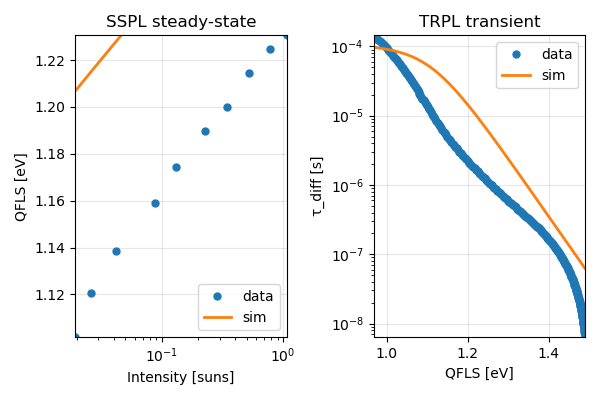

In [19]:
# ── Simulate steady-state + transient from best-fit (or custom) parameters ────
# Edit the block below to override fitted values, or leave as-is to replot
# exactly the best-fit result.
import constants

# ── Parameters (edit here) ────────────────────────────────────────────────────
krad_plot = results['krad_cm3s']                         # cm³/s
Et_plot   = results['params']['Et_eV'].values.copy()[0]     # eV,   one per trap
Nt_plot   = results['params']['Nt_1/cm3'].values.copy()[0]  # cm⁻³, one per trap
taun_plot = results['params']['tau_n_s'].values.copy()[0]   # s,    one per trap
taup_plot = results['params']['tau_p_s'].values.copy()[0]   # s,    one per trap


# Example: override individual values
# krad_plot    = 1e-11
# Et_plot     = np.array([ 1.5250]) #1.4750,
# Nt_plot     = np.array([4.7286e+17]) #6.9112e+16, 
# taun_plot   = np.array([ 8.6892e-09]) #5.9451e-08,
# taup_plot   = np.array([ 8.6892e-09]) #5.9451e-08,


#krad_plot    = 5.7871e-11
#Et_plot   = 1.3958
#Et_plot   = 1.5724
#Nt_plot   = 2.8703e+15
#Nt_plot   = 4.3392e+17
#taun_plot = 1.0482e-08
#taun_plot = 6.3897e-09
#taup_plot = 1.2305e-06
#taup_plot = 1.3652e-08

# ── Transient simulation ──────────────────────────────────────────────────────
(
    t, n_tr, p_tr, nt_tr, QFLS_tr, tau_tr, tau_tr_n, tau_tr_p, PL_tr,
    e_trapping_tr, e_detrapping_tr, h_trapping_tr, h_detrapping_tr, krad_rate_tr
) = trpl.solve_transient(
    tarr=[1e-10, 1e5],
    npulse=npulse,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300,
    bias=0
)

# ── Steady-state simulation ───────────────────────────────────────────────────
(
    narr, parr, ntmat, Rtotarr, Rradarr, Rsrhmat,
    qfls_ss, plqy_ss, tau_ss, tau_ss_n, tau_ss_p, nid,
    e_trapping, e_detrapping, h_trapping, h_detrapping
) = sspl.solve_steady_state(
    Npoints=1000,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300
)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

ax[0].semilogx(sspl_data.intensity_suns, sspl_data.qfls, 'o', ms=5, label='data')
ax[0].semilogx(Rtotarr / G, qfls_ss, lw=2, label='sim')
ax[0].set_ylabel('QFLS [eV]')
ax[0].set_xlabel('Intensity [suns]')
ax[0].set_title('SSPL steady-state')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(sspl_data.intensity_suns.min(), sspl_data.intensity_suns.max())
ax[0].set_ylim(sspl_data.qfls.min(), sspl_data.qfls.max())

ax[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, 'o', ms=5, label='data')
ax[1].semilogy(QFLS_tr, tau_tr, lw=2, label='sim')
ax[1].set_xlabel('QFLS [eV]')
ax[1].set_ylabel('τ_diff [s]')
ax[1].set_title('TRPL transient')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(trpl_data.qfls.min(), trpl_data.qfls.max())
ax[1].set_ylim(trpl_data.tau_diff.min(), trpl_data.tau_diff.max())

plt.tight_layout()
plt.show()



In [20]:
export_dir    = export_name  # created automatically if absent
export_prefix = "2traps-trpl-deeper-trap"

os.makedirs(export_dir, exist_ok=True)

export_transient = pd.DataFrame({
    't_s': t,
    'n_tr_cm3': n_tr,
    'p_tr_cm3': p_tr,
    **{f'nt_tr_cm3_{i}': nt_tr[:,i] for i in range(len(nt_tr[0]))},
    'QFLS_tr': QFLS_tr,
    'tau_tr_s': tau_tr,
    'tau_tr_n_s': tau_tr_n,
    'tau_tr_p_s': tau_tr_p,
    'PL_tr': PL_tr,
    **{f'e_trapping_cm3_s_{i}': e_trapping_tr[:, i] for i in range(e_trapping_tr.shape[1])},
    **{f'e_detrapping_cm3_s_{i}': e_detrapping_tr[:, i] for i in range(e_detrapping_tr.shape[1])},
    **{f'h_trapping_cm3_s_{i}': h_trapping_tr[:, i] for i in range(h_trapping_tr.shape[1])},
    **{f'h_detrapping_cm3_s_{i}': h_detrapping_tr[:, i] for i in range(h_detrapping_tr.shape[1])},
    'krad_rate_cm3_s': krad_rate_tr,

})

export_steady_state = pd.DataFrame({
    'narr_cm3': narr,
    'parr_cm3': parr,
    **{f'ntmat_cm3_{i}': ntmat[i] for i in range(len(ntmat))},
    'Rtotarr_cm3_s': Rtotarr,
    'Intensity_suns': Rtotarr / G,
    'Rradarr_cm3_s': Rradarr,
    **{f'Rsrhmat_cm3_s_{i}': Rsrhmat[i,:].tolist() for i in range(len(Rsrhmat))},
    'qfls_ss': qfls_ss,
    'plqy_ss': plqy_ss,
    'tau_ss': tau_ss,
    'tau_ss_n': tau_ss_n,
    'tau_ss_p': tau_ss_p,
    'nid': nid,
    **{f'e_trapping_{i}': e_trapping[i] for i in range(len(e_trapping))},
    **{f'e_detrapping_{i}': e_detrapping[i] for i in range(len(e_detrapping))},
    **{f'h_trapping_{i}': h_trapping[i] for i in range(len(h_trapping))},
    **{f'h_detrapping_{i}': h_detrapping[i] for i in range(len(h_detrapping))},
})

export_transient.to_csv(f"{export_dir}/{export_prefix}_transient.csv", index=False, float_format='%.6e')
export_steady_state.to_csv(f"{export_dir}/{export_prefix}_steady_state.csv", index=False, float_format='%.6e')
print(f"✓ Exported transient simulation to: {export_dir}/{export_prefix}_transient.csv")
print(f"✓ Exported steady-state simulation to: {export_dir}/{export_prefix}_steady_state.csv") 

✓ Exported transient simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl-deeper-trap_transient.csv
✓ Exported steady-state simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl-deeper-trap_steady_state.csv


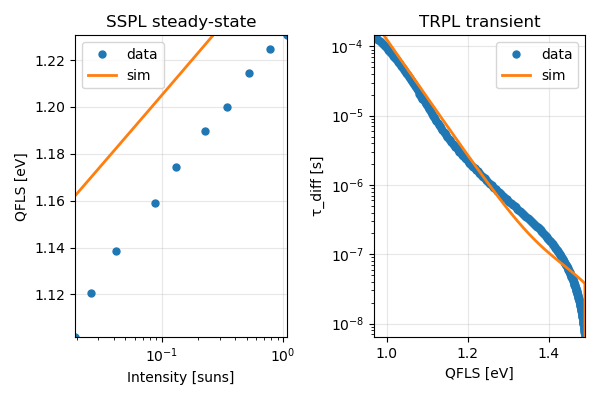

In [21]:
# ── Simulate steady-state + transient from best-fit (or custom) parameters ────
# Edit the block below to override fitted values, or leave as-is to replot
# exactly the best-fit result.
import constants

# ── Parameters (edit here) ────────────────────────────────────────────────────
krad_plot = results['krad_cm3s']                         # cm³/s
Et_plot   = results['params']['Et_eV'].values.copy()[1]     # eV,   one per trap
Nt_plot   = results['params']['Nt_1/cm3'].values.copy()[1]  # cm⁻³, one per trap
taun_plot = results['params']['tau_n_s'].values.copy()[1]   # s,    one per trap
taup_plot = results['params']['tau_p_s'].values.copy()[1]   # s,    one per trap


# Example: override individual values
# krad_plot    = 1e-11
# Et_plot     = np.array([ 1.5250]) #1.4750,
# Nt_plot     = np.array([4.7286e+17]) #6.9112e+16, 
# taun_plot   = np.array([ 8.6892e-09]) #5.9451e-08,
# taup_plot   = np.array([ 8.6892e-09]) #5.9451e-08,


#krad_plot    = 5.7871e-11
#Et_plot   = 1.3958
#Et_plot   = 1.5724
#Nt_plot   = 2.8703e+15
#Nt_plot   = 4.3392e+17
#taun_plot = 1.0482e-08
#taun_plot = 6.3897e-09
#taup_plot = 1.2305e-06
#taup_plot = 1.3652e-08

# ── Transient simulation ──────────────────────────────────────────────────────
(
    t, n_tr, p_tr, nt_tr, QFLS_tr, tau_tr, tau_tr_n, tau_tr_p, PL_tr,
    e_trapping_tr, e_detrapping_tr, h_trapping_tr, h_detrapping_tr, krad_rate_tr
) = trpl.solve_transient(
    tarr=[1e-10, 1e5],
    npulse=npulse,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300,
    bias=0
)

# ── Steady-state simulation ───────────────────────────────────────────────────
(
    narr, parr, ntmat, Rtotarr, Rradarr, Rsrhmat,
    qfls_ss, plqy_ss, tau_ss, tau_ss_n, tau_ss_p, nid,
    e_trapping, e_detrapping, h_trapping, h_detrapping
) = sspl.solve_steady_state(
    Npoints=1000,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300
)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

ax[0].semilogx(sspl_data.intensity_suns, sspl_data.qfls, 'o', ms=5, label='data')
ax[0].semilogx(Rtotarr / G, qfls_ss, lw=2, label='sim')
ax[0].set_ylabel('QFLS [eV]')
ax[0].set_xlabel('Intensity [suns]')
ax[0].set_title('SSPL steady-state')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(sspl_data.intensity_suns.min(), sspl_data.intensity_suns.max())
ax[0].set_ylim(sspl_data.qfls.min(), sspl_data.qfls.max())

ax[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, 'o', ms=5, label='data')
ax[1].semilogy(QFLS_tr, tau_tr, lw=2, label='sim')
ax[1].set_xlabel('QFLS [eV]')
ax[1].set_ylabel('τ_diff [s]')
ax[1].set_title('TRPL transient')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(trpl_data.qfls.min(), trpl_data.qfls.max())
ax[1].set_ylim(trpl_data.tau_diff.min(), trpl_data.tau_diff.max())

plt.tight_layout()
plt.show()



In [22]:
export_dir    = export_name  # created automatically if absent
export_prefix = "2traps-trpl-shallower-trap"

os.makedirs(export_dir, exist_ok=True)

export_transient = pd.DataFrame({
    't_s': t,
    'n_tr_cm3': n_tr,
    'p_tr_cm3': p_tr,
    **{f'nt_tr_cm3_{i}': nt_tr[:,i] for i in range(len(nt_tr[0]))},
    'QFLS_tr': QFLS_tr,
    'tau_tr_s': tau_tr,
    'tau_tr_n_s': tau_tr_n,
    'tau_tr_p_s': tau_tr_p,
    'PL_tr': PL_tr,
    **{f'e_trapping_cm3_s_{i}': e_trapping_tr[:, i] for i in range(e_trapping_tr.shape[1])},
    **{f'e_detrapping_cm3_s_{i}': e_detrapping_tr[:, i] for i in range(e_detrapping_tr.shape[1])},
    **{f'h_trapping_cm3_s_{i}': h_trapping_tr[:, i] for i in range(h_trapping_tr.shape[1])},
    **{f'h_detrapping_cm3_s_{i}': h_detrapping_tr[:, i] for i in range(h_detrapping_tr.shape[1])},
    'krad_rate_cm3_s': krad_rate_tr,

})

export_steady_state = pd.DataFrame({
    'narr_cm3': narr,
    'parr_cm3': parr,
    **{f'ntmat_cm3_{i}': ntmat[i] for i in range(len(ntmat))},
    'Rtotarr_cm3_s': Rtotarr,
    'Intensity_suns': Rtotarr / G,
    'Rradarr_cm3_s': Rradarr,
    **{f'Rsrhmat_cm3_s_{i}': Rsrhmat[i,:].tolist() for i in range(len(Rsrhmat))},
    'qfls_ss': qfls_ss,
    'plqy_ss': plqy_ss,
    'tau_ss': tau_ss,
    'tau_ss_n': tau_ss_n,
    'tau_ss_p': tau_ss_p,
    'nid': nid,
    **{f'e_trapping_{i}': e_trapping[i] for i in range(len(e_trapping))},
    **{f'e_detrapping_{i}': e_detrapping[i] for i in range(len(e_detrapping))},
    **{f'h_trapping_{i}': h_trapping[i] for i in range(len(h_trapping))},
    **{f'h_detrapping_{i}': h_detrapping[i] for i in range(len(h_detrapping))},
})

export_transient.to_csv(f"{export_dir}/{export_prefix}_transient.csv", index=False, float_format='%.6e')
export_steady_state.to_csv(f"{export_dir}/{export_prefix}_steady_state.csv", index=False, float_format='%.6e')
print(f"✓ Exported transient simulation to: {export_dir}/{export_prefix}_transient.csv")
print(f"✓ Exported steady-state simulation to: {export_dir}/{export_prefix}_steady_state.csv") 

✓ Exported transient simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl-shallower-trap_transient.csv
✓ Exported steady-state simulation to: fit-ye-genghua-low-Nt-no-photodoping-2traps-3/2traps-trpl-shallower-trap_steady_state.csv


### Startpoints trap analysis


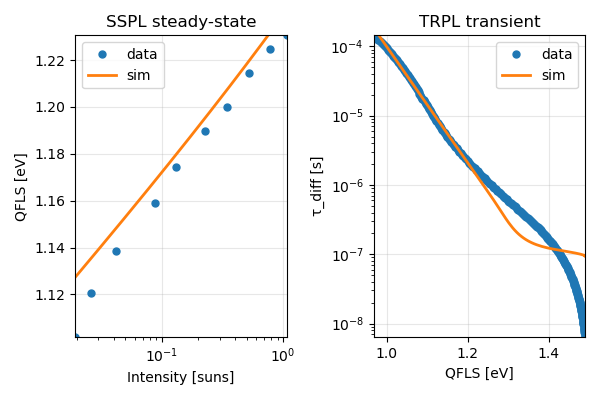

In [40]:
# ── Simulate steady-state + transient from best-fit (or custom) parameters ────
# Edit the block below to override fitted values, or leave as-is to replot
# exactly the best-fit result.


# ── Parameters (edit here) ────────────────────────────────────────────────────

# start_point / start_point_2 layout: (krad, Et, Nt, tau_n, tau_p)

krad_plot = float(start_point[0])     
Et_plot =  float(start_point[1])
Nt_plot = float(start_point[2]) 
taun_plot = float(start_point[3])
taup_plot = float(start_point[4])

# Example: override individual values



#krad_plot    = 5.7871e-11
#Et_plot   = 1.3958
#Et_plot   = 1.5724
#Nt_plot   = 2.8703e+15
#Nt_plot   = 4.3392e+17
#taun_plot = 1.0482e-08
#taun_plot = 6.3897e-09
#taup_plot = 1.2305e-06
#taup_plot = 1.3652e-08

# ── Transient simulation ──────────────────────────────────────────────────────
(
    t, n_tr, p_tr, nt_tr, QFLS_tr, tau_tr, tau_tr_n, tau_tr_p, PL_tr,
    e_trapping_tr, e_detrapping_tr, h_trapping_tr, h_detrapping_tr, krad_rate_tr
) = trpl.solve_transient(
    tarr=[1e-10, 1e5],
    npulse=npulse,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300,
    bias=0
)

# ── Steady-state simulation ───────────────────────────────────────────────────
(
    narr, parr, ntmat, Rtotarr, Rradarr, Rsrhmat,
    qfls_ss, plqy_ss, tau_ss, tau_ss_n, tau_ss_p, nid,
    e_trapping, e_detrapping, h_trapping, h_detrapping
) = sspl.solve_steady_state(
    Npoints=1000,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300
)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

ax[0].semilogx(sspl_data.intensity_suns, sspl_data.qfls, 'o', ms=5, label='data')
ax[0].semilogx(Rtotarr / G, qfls_ss, lw=2, label='sim')
ax[0].set_ylabel('QFLS [eV]')
ax[0].set_xlabel('Intensity [suns]')
ax[0].set_title('SSPL steady-state')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(sspl_data.intensity_suns.min(), sspl_data.intensity_suns.max())
ax[0].set_ylim(sspl_data.qfls.min(), sspl_data.qfls.max())

ax[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, 'o', ms=5, label='data')
ax[1].semilogy(QFLS_tr, tau_tr, lw=2, label='sim')
ax[1].set_xlabel('QFLS [eV]')
ax[1].set_ylabel('τ_diff [s]')
ax[1].set_title('TRPL transient')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(trpl_data.qfls.min(), trpl_data.qfls.max())
ax[1].set_ylim(trpl_data.tau_diff.min(), trpl_data.tau_diff.max())

plt.tight_layout()
plt.show()



In [41]:
export_dir    = "fit-ye-genghua-2traps-trials-1-sspl-trpl"   # created automatically if absent
export_prefix = "2traps-trpl-shallower-trap_startpoint_trap_1"

os.makedirs(export_dir, exist_ok=True)

export_transient = pd.DataFrame({
    't_s': t,
    'n_tr_cm3': n_tr,
    'p_tr_cm3': p_tr,
    **{f'nt_tr_cm3_{i}': nt_tr[:,i] for i in range(len(nt_tr[0]))},
    'QFLS_tr': QFLS_tr,
    'tau_tr_s': tau_tr,
    'tau_tr_n_s': tau_tr_n,
    'tau_tr_p_s': tau_tr_p,
    'PL_tr': PL_tr,
    **{f'e_trapping_cm3_s_{i}': e_trapping_tr[:, i] for i in range(e_trapping_tr.shape[1])},
    **{f'e_detrapping_cm3_s_{i}': e_detrapping_tr[:, i] for i in range(e_detrapping_tr.shape[1])},
    **{f'h_trapping_cm3_s_{i}': h_trapping_tr[:, i] for i in range(h_trapping_tr.shape[1])},
    **{f'h_detrapping_cm3_s_{i}': h_detrapping_tr[:, i] for i in range(h_detrapping_tr.shape[1])},
    'krad_rate_cm3_s': krad_rate_tr,

})

export_steady_state = pd.DataFrame({
    'narr_cm3': narr,
    'parr_cm3': parr,
    **{f'ntmat_cm3_{i}': ntmat[i] for i in range(len(ntmat))},
    'Rtotarr_cm3_s': Rtotarr,
    'Intensity_suns': Rtotarr / G,
    'Rradarr_cm3_s': Rradarr,
    **{f'Rsrhmat_cm3_s_{i}': Rsrhmat[i,:].tolist() for i in range(len(Rsrhmat))},
    'qfls_ss': qfls_ss,
    'plqy_ss': plqy_ss,
    'tau_ss': tau_ss,
    'tau_ss_n': tau_ss_n,
    'tau_ss_p': tau_ss_p,
    'nid': nid,
    **{f'e_trapping_{i}': e_trapping[i] for i in range(len(e_trapping))},
    **{f'e_detrapping_{i}': e_detrapping[i] for i in range(len(e_detrapping))},
    **{f'h_trapping_{i}': h_trapping[i] for i in range(len(h_trapping))},
    **{f'h_detrapping_{i}': h_detrapping[i] for i in range(len(h_detrapping))},
})

export_transient.to_csv(f"{export_dir}/{export_prefix}_transient.csv", index=False, float_format='%.6e')
export_steady_state.to_csv(f"{export_dir}/{export_prefix}_steady_state.csv", index=False, float_format='%.6e')
print(f"✓ Exported transient simulation to: {export_dir}/{export_prefix}_transient.csv")
print(f"✓ Exported steady-state simulation to: {export_dir}/{export_prefix}_steady_state.csv") 

✓ Exported transient simulation to: fit-ye-genghua-2traps-trials-1-sspl-trpl/2traps-trpl-shallower-trap_startpoint_trap_1_transient.csv
✓ Exported steady-state simulation to: fit-ye-genghua-2traps-trials-1-sspl-trpl/2traps-trpl-shallower-trap_startpoint_trap_1_steady_state.csv


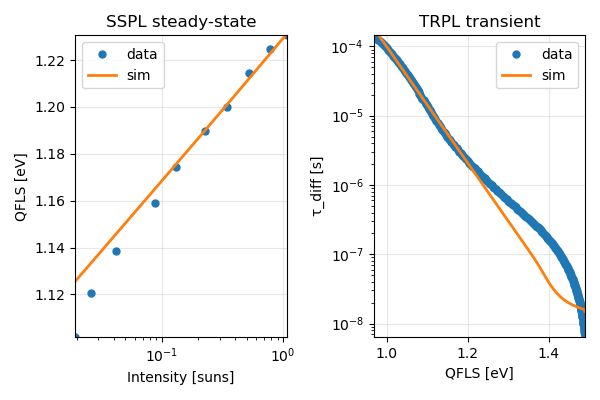

In [42]:
# ── Simulate steady-state + transient from best-fit (or custom) parameters ────
# Edit the block below to override fitted values, or leave as-is to replot
# exactly the best-fit result.


# ── Parameters (edit here) ────────────────────────────────────────────────────

# start_point / start_point_2 layout: (krad, Et, Nt, tau_n, tau_p)

krad_plot = float(start_point_2[0])     
Et_plot =  float(start_point_2[1])
Nt_plot = float(start_point_2[2]) 
taun_plot = float(start_point_2[3])
taup_plot = float(start_point_2[4])

# Example: override individual values



#krad_plot    = 5.7871e-11
#Et_plot   = 1.3958
#Et_plot   = 1.5724
#Nt_plot   = 2.8703e+15
#Nt_plot   = 4.3392e+17
#taun_plot = 1.0482e-08
#taun_plot = 6.3897e-09
#taup_plot = 1.2305e-06
#taup_plot = 1.3652e-08

# ── Transient simulation ──────────────────────────────────────────────────────
(
    t, n_tr, p_tr, nt_tr, QFLS_tr, tau_tr, tau_tr_n, tau_tr_p, PL_tr,
    e_trapping_tr, e_detrapping_tr, h_trapping_tr, h_detrapping_tr, krad_rate_tr
) = trpl.solve_transient(
    tarr=[1e-10, 1e5],
    npulse=npulse,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300,
    bias=0
)

# ── Steady-state simulation ───────────────────────────────────────────────────
(
    narr, parr, ntmat, Rtotarr, Rradarr, Rsrhmat,
    qfls_ss, plqy_ss, tau_ss, tau_ss_n, tau_ss_p, nid,
    e_trapping, e_detrapping, h_trapping, h_detrapping
) = sspl.solve_steady_state(
    Npoints=1000,
    Eg=Eg,
    Nc=constants.NC,
    Nv=constants.NV,
    krad=krad_plot,
    Nt=Nt_plot,
    Et=Et_plot,
    taun=taun_plot,
    taup=taup_plot,
    T=300
)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

ax[0].semilogx(sspl_data.intensity_suns, sspl_data.qfls, 'o', ms=5, label='data')
ax[0].semilogx(Rtotarr / G, qfls_ss, lw=2, label='sim')
ax[0].set_ylabel('QFLS [eV]')
ax[0].set_xlabel('Intensity [suns]')
ax[0].set_title('SSPL steady-state')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(sspl_data.intensity_suns.min(), sspl_data.intensity_suns.max())
ax[0].set_ylim(sspl_data.qfls.min(), sspl_data.qfls.max())

ax[1].semilogy(trpl_data.qfls, trpl_data.tau_diff, 'o', ms=5, label='data')
ax[1].semilogy(QFLS_tr, tau_tr, lw=2, label='sim')
ax[1].set_xlabel('QFLS [eV]')
ax[1].set_ylabel('τ_diff [s]')
ax[1].set_title('TRPL transient')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(trpl_data.qfls.min(), trpl_data.qfls.max())
ax[1].set_ylim(trpl_data.tau_diff.min(), trpl_data.tau_diff.max())

plt.tight_layout()
plt.show()



In [43]:
export_dir    = "fit-ye-genghua-2traps-trials-1-sspl-trpl"   # created automatically if absent
export_prefix = "2traps-trpl-shallower-trap_startpoint_trap_2"

os.makedirs(export_dir, exist_ok=True)

export_transient = pd.DataFrame({
    't_s': t,
    'n_tr_cm3': n_tr,
    'p_tr_cm3': p_tr,
    **{f'nt_tr_cm3_{i}': nt_tr[:,i] for i in range(len(nt_tr[0]))},
    'QFLS_tr': QFLS_tr,
    'tau_tr_s': tau_tr,
    'tau_tr_n_s': tau_tr_n,
    'tau_tr_p_s': tau_tr_p,
    'PL_tr': PL_tr,
    **{f'e_trapping_cm3_s_{i}': e_trapping_tr[:, i] for i in range(e_trapping_tr.shape[1])},
    **{f'e_detrapping_cm3_s_{i}': e_detrapping_tr[:, i] for i in range(e_detrapping_tr.shape[1])},
    **{f'h_trapping_cm3_s_{i}': h_trapping_tr[:, i] for i in range(h_trapping_tr.shape[1])},
    **{f'h_detrapping_cm3_s_{i}': h_detrapping_tr[:, i] for i in range(h_detrapping_tr.shape[1])},
    'krad_rate_cm3_s': krad_rate_tr,

})

export_steady_state = pd.DataFrame({
    'narr_cm3': narr,
    'parr_cm3': parr,
    **{f'ntmat_cm3_{i}': ntmat[i] for i in range(len(ntmat))},
    'Rtotarr_cm3_s': Rtotarr,
    'Intensity_suns': Rtotarr / G,
    'Rradarr_cm3_s': Rradarr,
    **{f'Rsrhmat_cm3_s_{i}': Rsrhmat[i,:].tolist() for i in range(len(Rsrhmat))},
    'qfls_ss': qfls_ss,
    'plqy_ss': plqy_ss,
    'tau_ss': tau_ss,
    'tau_ss_n': tau_ss_n,
    'tau_ss_p': tau_ss_p,
    'nid': nid,
    **{f'e_trapping_{i}': e_trapping[i] for i in range(len(e_trapping))},
    **{f'e_detrapping_{i}': e_detrapping[i] for i in range(len(e_detrapping))},
    **{f'h_trapping_{i}': h_trapping[i] for i in range(len(h_trapping))},
    **{f'h_detrapping_{i}': h_detrapping[i] for i in range(len(h_detrapping))},
})

export_transient.to_csv(f"{export_dir}/{export_prefix}_transient.csv", index=False, float_format='%.6e')
export_steady_state.to_csv(f"{export_dir}/{export_prefix}_steady_state.csv", index=False, float_format='%.6e')
print(f"✓ Exported transient simulation to: {export_dir}/{export_prefix}_transient.csv")
print(f"✓ Exported steady-state simulation to: {export_dir}/{export_prefix}_steady_state.csv") 

✓ Exported transient simulation to: fit-ye-genghua-2traps-trials-1-sspl-trpl/2traps-trpl-shallower-trap_startpoint_trap_2_transient.csv
✓ Exported steady-state simulation to: fit-ye-genghua-2traps-trials-1-sspl-trpl/2traps-trpl-shallower-trap_startpoint_trap_2_steady_state.csv
